# Collaborative Filtering — Neural Network Embeddings

This notebook trains a neural network that learns low-dimensional embedding vectors for users and courses. Interactions are predicted via dot product + bias terms in a binary classification setup.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
print('TF version:', tf.__version__)

ratings_df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/ratings.csv')
course_df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/course_genre.csv')
print('Ratings:', ratings_df.shape, '| Courses:', course_df.shape)

TF version: 2.20.0
Ratings: (233306, 3) | Courses: (307, 16)


## 2. Encode Users & Items

In [2]:
# Encode user and item IDs to integer indices
user_ids = ratings_df['user'].unique()
item_ids = ratings_df['item'].unique()

user2idx = {u: i for i, u in enumerate(user_ids)}
item2idx = {c: i for i, c in enumerate(item_ids)}

ratings_df['user_idx'] = ratings_df['user'].map(user2idx)
ratings_df['item_idx'] = ratings_df['item'].map(item2idx)

n_users = len(user_ids)
n_items = len(item_ids)
print(f'Total users: {n_users}, total items: {n_items}')

Total users: 33901, total items: 126


## 3. Create Negative Samples & Train/Test Split

In [3]:
from sklearn.model_selection import train_test_split

# Positive interactions
pos = ratings_df[['user_idx','item_idx']].values
pos_labels = np.ones(len(pos))

# Generate negative samples (user-item pairs not in dataset)
rng = np.random.default_rng(42)
neg_user = rng.integers(0, n_users, size=len(pos))
neg_item = rng.integers(0, n_items, size=len(pos))
neg = np.stack([neg_user, neg_item], axis=1)
neg_labels = np.zeros(len(neg))

X = np.vstack([pos, neg])
y = np.concatenate([pos_labels, neg_labels])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (373289, 2), Test: (93323, 2)


## 4. Define Embedding Model

In [4]:
EMBEDDING_DIM = 16

def build_embedding_model(n_users, n_items, embedding_dim=16):
    user_input = keras.Input(shape=(1,), name='user_input')
    item_input = keras.Input(shape=(1,), name='item_input')
    
    user_emb = layers.Embedding(n_users, embedding_dim, name='user_embedding')(user_input)
    item_emb = layers.Embedding(n_items, embedding_dim, name='item_embedding')(item_input)
    
    user_vec = layers.Flatten()(user_emb)
    item_vec = layers.Flatten()(item_emb)
    
    dot = layers.Dot(axes=1)([user_vec, item_vec])
    output = layers.Dense(1, activation='sigmoid')(dot)
    
    model = keras.Model(inputs=[user_input, item_input], outputs=output)
    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=[tf.keras.metrics.RootMeanSquaredError()])
    return model

model = build_embedding_model(n_users, n_items, EMBEDDING_DIM)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 16)     │    542,416 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_embedding      │ (None, 1, 16)     │      2,016 │ item_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16)        │          0 │ user_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 16)        │          0 │ item_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 1)         │          0 │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │          2 │ dot[0][0]         │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 544,434 (2.08 MB)

 Trainable params: 544,434 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Train Model

In [5]:
history = model.fit(
    [X_train[:,0], X_train[:,1]], y_train,
    validation_split=0.1,
    epochs=10, batch_size=64, verbose=1
)

Epoch 1/10
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 36s 7ms/step - loss: 0.5937 - root_mean_squared_error: 0.4522 - val_loss: 0.4889 - val_root_mean_squared_error: 0.3993
Epoch 2/10
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 114s 21ms/step - loss: 0.3793 - root_mean_squared_error: 0.3448 - val_loss: 0.4559 - val_root_mean_squared_error: 0.3797
Epoch 3/10
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - loss: 0.2568 - root_mean_squared_error: 0.2770 - val_loss: 0.4893 - val_root_mean_squared_error: 0.3848
Epoch 4/10
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step - loss: 0.1741 - root_mean_squared_error: 0.2245 - val_loss: 0.5632 - val_root_mean_squared_error: 0.3988
Epoch 5/10
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - loss: 0.1264 - root_mean_squared_error: 0.1906 - val_loss: 0.6518 - val_root_mean_squared_error: 0.4127
Epoch 6/10
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - loss: 0.1009 - root_mean_squared_error: 0.1712 - val_loss: 0.7273 - val_root_mean_squared_error: 0.4237
Epoch 7/10
5250/5250 ━━━━━━━━━━━

Test Loss: 0.935178
Test RMSE: 0.4462


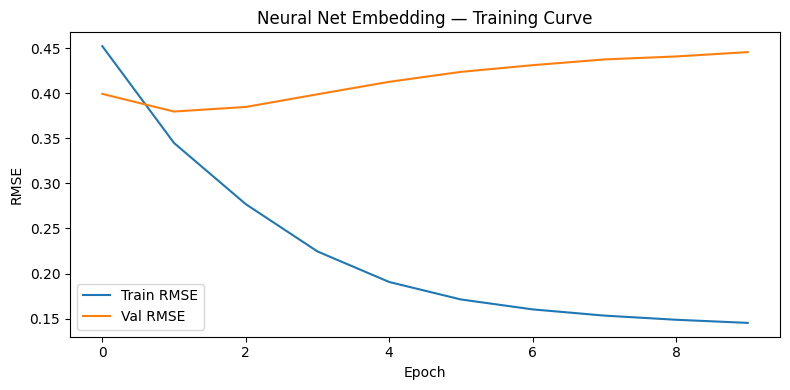

In [6]:
test_loss, test_rmse = model.evaluate([X_test[:,0], X_test[:,1]], y_test, verbose=0)
print(f'Test Loss: {test_loss:.6f}')
print(f'Test RMSE: {test_rmse:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(history.history['root_mean_squared_error'], label='Train RMSE')
plt.plot(history.history['val_root_mean_squared_error'], label='Val RMSE')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('Neural Net Embedding — Training Curve')
plt.legend()
plt.tight_layout()
plt.savefig('nn_training_curve.png', dpi=120, bbox_inches='tight')
plt.show()

## Final Summary

| Collaborative Filtering | **NN Embeddings** | RMSE:**0.4462** |
